In [1]:
import pandas as pd


In [2]:
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
demo_2011 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Demographics_data/2011-12/DEMO_G.xpt.txt')
cbc_2011 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Laboratory_data/2011-12/CBC_G.xpt.txt')

demo_2013 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Demographics_data/2013-14/DEMO_H.xpt.txt')
cbc_2013 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Laboratory_data/2013-14/CBC_H.xpt.txt')

demo_2015 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Demographics_data/2015-16/DEMO_I.xpt.txt')
cbc_2015 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Laboratory_data/2015-16/CBC_I.xpt.txt')

demo_2017 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Demographics_data/2017-20/P_DEMO.xpt.txt')
cbc_2017 = pd.read_sas('/Users/anuj/Documents/DataSet\'s/Cell_Prediction_data/Laboratory_data/2017-20/P_CBC.xpt.txt')



df_2011 = pd.merge(demo_2011, cbc_2011, on = 'SEQN')

df_2013 = pd.merge(demo_2013, cbc_2013, on = 'SEQN')

df_2015 = pd.merge(demo_2015, cbc_2015, on = 'SEQN')

df_2017 = pd.merge(demo_2017, cbc_2017, on = 'SEQN')


df_2011.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGY,...,LBDBANO,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXMCHSI,LBXMC,LBXRDW,LBXPLTSI,LBXMPSI
0,62161.0,7.0,2.0,1.0,22.0,NaN,3.0,3.0,2.0,NaN,...,1.000000e-01,5.29,16.4,45.9,88.4,31.4,35.6,11.8,223.0,7.6
1,62162.0,7.0,2.0,2.0,3.0,NaN,1.0,1.0,1.0,3.0,...,5.397605e-79,4.97,14.1,40.2,81.0,28.4,35.1,13.4,259.0,7.2
2,62163.0,7.0,2.0,1.0,14.0,NaN,5.0,6.0,2.0,14.0,...,1.000000e-01,4.65,13.7,42.2,90.6,29.5,32.5,12.6,259.0,7.6
3,62164.0,7.0,2.0,2.0,44.0,NaN,3.0,3.0,1.0,NaN,...,1.000000e-01,4.21,12.8,38.9,92.4,30.3,32.8,14.1,297.0,8.6
4,62165.0,7.0,2.0,2.0,14.0,NaN,4.0,4.0,2.0,14.0,...,1.000000e-01,4.80,12.9,38.2,79.6,26.8,33.7,12.9,257.0,9.1


In [4]:
# Adding cycle Lable for Analysis. 

df_2011['cycle'] = '2011-2012'
df_2013['cycle'] = '2013-2014'
df_2015['cycle'] = '2015-2016'
df_2017['cycle'] = '2017-2020'

In [5]:
# Combining all cycles

df_all = pd.concat(
    [df_2011, 
     df_2013, 
     df_2015, 
     df_2017], 
    ignore_index=True)
    

In [6]:
df_all.shape

(41315, 74)

In [7]:
features = [
    "LBXWBCSI",   # WBC
    "LBXRBCSI",   # RBC
    "LBXHGB",     # Hemoglobin
    "LBXHCT",     # Hematocrit
    "LBXMCVSI",   # MCV
    "LBXRDW",     # RDW
    "LBXPLTSI"    # Platelets
]

target = "RIDAGEYR"

df_model = df_all[features + [target]].dropna()

In [8]:
df_all.shape

(41315, 74)

In [9]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.3837309589691873
MAE: 15.508711558902174


In [12]:
import pandas as pd

coefficients = pd.Series(model.coef_, index=features)
print(coefficients.sort_values())

LBXHGB      -4.374110
LBXHCT      -1.912543
LBXPLTSI    -0.070378
LBXWBCSI     0.236851
LBXMCVSI     3.689194
LBXRDW       6.759862
LBXRBCSI    32.707210
dtype: float64


<Axes: >

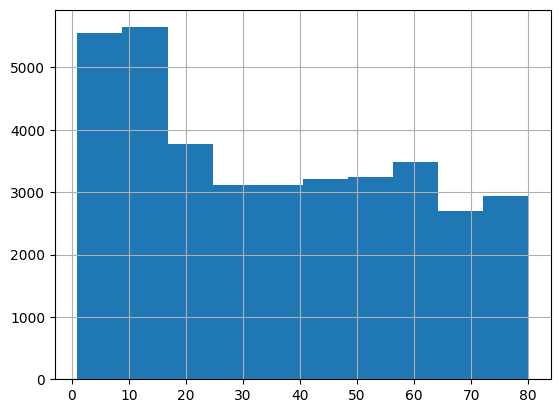

In [13]:
y.hist()

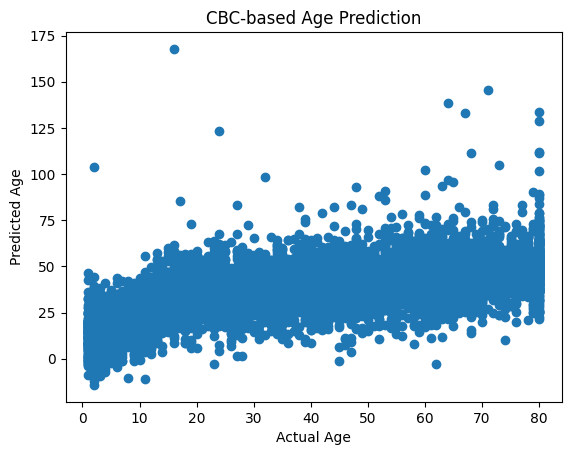

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("CBC-based Age Prediction")
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample